# Africa Tiny U-Net v1 — strict consensus + GEE-screened no-fire negatives

This Colab notebook downloads a bounded Africa subset, creates strict voting masks, adds only safe non-fire patches, runs Ground Gate 1, trains a lightweight B10 Tiny U-Net, and exports the checkpoint, ONNX model, metrics, and figures.

In [1]:
!df -h /content
!pip -q install gdown rasterio tqdm pandas numpy matplotlib scipy onnx

from google.colab import drive
drive.mount("/content/drive")

PROJECT_ZIP = "/content/drive/MyDrive/thermal-edge-fire.zip"  # Change only if your ZIP is elsewhere.
assert __import__("os").path.exists(PROJECT_ZIP), f"Project ZIP not found: {PROJECT_ZIP}"

!rm -rf /content/thermal-edge-fire
!unzip -q "$PROJECT_ZIP" -d /content
%cd /content/thermal-edge-fire
print("Project extracted.")


Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  43% /
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 30.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
Mounted at /content/drive
/content/thermal-edge-fire
Project extracted.


In [ ]:
from pathlib import Path

DATA_DIR = Path("/content")
AFRICA_ARCHIVE = DATA_DIR / "Africa.zip"

AFRICA_URL = "https://drive.google.com/file/d/1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX/view"

if not AFRICA_ARCHIVE.exists():
    !gdown --fuzzy "$AFRICA_URL" -O "$AFRICA_ARCHIVE"

assert AFRICA_ARCHIVE.exists(), "Africa.zip download failed."
print("Archive size (GB):", round(AFRICA_ARCHIVE.stat().st_size / 1024**3, 2))


Downloading...
From (original): https://drive.google.com/uc?id=1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX
From (redirected): https://drive.google.com/uc?id=1Ng3JwsjJPApshk8lJdGcsNHI52NaEMDX&confirm=t&uuid=6a1c514d-a471-414b-9651-8872c3d50b9f
To: /content/Africa.zip
 70% 22.2G/31.7G [04:21<02:49, 56.1MB/s]

In [ ]:
!pip -q install earthengine-api rasterio requests tqdm pandas

import ee
import os
import io
import csv
import zipfile
import random
import requests
import rasterio
import numpy as np
import pandas as pd

# Create/select an Earth Engine-enabled Google Cloud project, then place its ID here.
GEE_PROJECT = "REPLACE_WITH_YOUR_GOOGLE_CLOUD_PROJECT_ID"

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)

print("Earth Engine authenticated.")

In [ ]:
# ================================================================
# GEE NO-FIRE PATCH CREATION — AFRICA V3
#
# Uses raw Landsat 8 Collection 2 Tier 1 imagery, matching the
# raw-DN style of your ActiveFire workflow.
#
# Fire screening:
# - no MODIS FireMask class 7/8/9 within 12 km
# - screen ±8 days around the Landsat acquisition
# - reject cloudy / fill / shadow / snow patches
# ================================================================

from pathlib import Path
from tqdm.auto import tqdm

SEED = 42
TARGET_NEGATIVES = 150  # First validate 150. Later increase to 500–1,000.
MAX_ATTEMPTS = 2500

PATCH_PIXELS = 256
PIXEL_SIZE_M = 30
HALF_PATCH_M = PATCH_PIXELS * PIXEL_SIZE_M / 2  # 3,840 m
FIRE_EXCLUSION_M = 12_000
MAX_BAD_QA_FRACTION = 0.01

# Keep ten bands, where B10 and B11 have indexes 8 and 9.
# This matches your current project's channels=(8,) convention.
BANDS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B9", "B10", "B11"]

GEE_ROOT = Path("/content/gee_nonfire_v3")
GEE_PATCH_DIR = GEE_ROOT / "patches"
GEE_MASK_DIR = GEE_ROOT / "masks" / "nonfire"
GEE_PATCH_DIR.mkdir(parents=True, exist_ok=True)
GEE_MASK_DIR.mkdir(parents=True, exist_ok=True)

LANDSAT = ee.ImageCollection("LANDSAT/LC08/C02/T1")
MODIS_FIRE = ee.ImageCollection("MODIS/061/MOD14A1")

# Prefer hot, difficult no-fire terrain; not only easy green background.
REGIONS = [
    ("north_africa_med", (-18, 27, 36, 46), 0.65),
    ("sub_saharan", (-18, -35, 52, 27), 0.35),
]

rng = random.Random(SEED)

def random_point():
    choice = rng.random()
    cumulative = 0.0

    for region_name, bounds, weight in REGIONS:
        cumulative += weight
        if choice <= cumulative:
            west, south, east, north = bounds
            return (
                region_name,
                rng.uniform(west, east),
                rng.uniform(south, north),
            )

    region_name, bounds, _ = REGIONS[-1]
    west, south, east, north = bounds
    return region_name, rng.uniform(west, east), rng.uniform(south, north)


def qa_bad_fraction(image, patch):
    """Fraction of fill/cloud/shadow/snow pixels in the proposed patch."""
    qa = image.select("QA_PIXEL")

    bad = (
        qa.bitwiseAnd(1 << 0).neq(0)  # fill
        .Or(qa.bitwiseAnd(1 << 1).neq(0))  # dilated cloud
        .Or(qa.bitwiseAnd(1 << 3).neq(0))  # cloud
        .Or(qa.bitwiseAnd(1 << 4).neq(0))  # cloud shadow
        .Or(qa.bitwiseAnd(1 << 5).neq(0))  # snow
    )

    value = bad.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=patch,
        scale=30,
        maxPixels=1e7,
    ).get("QA_PIXEL")

    return value.getInfo()


def has_nearby_modis_fire(acquisition_date, point):
    """Reject if MODIS reports fire in a broad spatial/temporal buffer."""
    fire_window = MODIS_FIRE.filterDate(
        acquisition_date.advance(-8, "day"),
        acquisition_date.advance(9, "day"),
    )

    fire_image = fire_window.select("FireMask").max()
    fire_pixels = fire_image.gte(7)  # classes 7, 8, 9 are low/nominal/high-confidence fire.

    value = fire_pixels.reduceRegion(
        reducer=ee.Reducer.max(),
        geometry=point.buffer(FIRE_EXCLUSION_M),
        scale=1000,
        maxPixels=1e7,
    ).get("FireMask")

    return bool(value.getInfo() or 0)


def download_multiband_patch(image, patch, filename):
    """Download one ten-band GeoTIFF to /content."""
    url = image.select(BANDS).clip(patch).getDownloadURL(
        {
            "name": filename,
            "region": patch.coordinates().getInfo(),
            "scale": PIXEL_SIZE_M,
            "filePerBand": False,
            "format": "GEO_TIFF",
        }
    )

    response = requests.get(url, timeout=180)
    response.raise_for_status()

    output_path = GEE_PATCH_DIR / f"{filename}.tif"

    # Earth Engine usually returns a ZIP containing a TIFF.
    if zipfile.is_zipfile(io.BytesIO(response.content)):
        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            tif_names = [
                name for name in archive.namelist()
                if name.lower().endswith(".tif")
            ]
            if not tif_names:
                raise RuntimeError("Earth Engine download contained no GeoTIFF.")

            with archive.open(tif_names[0]) as source, open(output_path, "wb") as destination:
                destination.write(source.read())
    else:
        with open(output_path, "wb") as destination:
            destination.write(response.content)

    return output_path


records = []
attempts = 0

with tqdm(total=TARGET_NEGATIVES, desc="Downloading screened no-fire patches") as progress:
    while len(records) < TARGET_NEGATIVES and attempts < MAX_ATTEMPTS:
        attempts += 1

        region_name, lon, lat = random_point()
        point = ee.Geometry.Point([lon, lat])
        patch = point.buffer(HALF_PATCH_M).bounds()

        # 2020 matches the date range of your ActiveFire subset.
        image = (
            LANDSAT
            .filterBounds(patch)
            .filterDate("2020-06-01", "2020-10-01")
            .filter(ee.Filter.lt("CLOUD_COVER", 10))
            .sort("CLOUD_COVER")
            .first()
        )

        info = image.getInfo()
        if info is None:
            continue

        acquisition_date = ee.Date(image.get("system:time_start"))

        try:
            bad_fraction = qa_bad_fraction(image, patch)

            if bad_fraction is None or bad_fraction > MAX_BAD_QA_FRACTION:
                continue

            if has_nearby_modis_fire(acquisition_date, point):
                continue

            date_text = acquisition_date.format("YYYYMMdd").getInfo()
            scene_id = image.get("LANDSAT_PRODUCT_ID").getInfo()
            filename = (
                f"GEE_LC08_{region_name}_{date_text}_"
                f"{len(records):04d}"
            )

            image_path = download_multiband_patch(image, patch, filename)
            mask_path = GEE_MASK_DIR / f"{filename}_nonfire.tif"

            with rasterio.open(image_path) as src:
                # Compatibility checks before accepting the patch.
                if src.count != 10:
                    image_path.unlink(missing_ok=True)
                    continue

                profile = src.profile.copy()
                profile.pop("blockxsize", None)
                profile.pop("blockysize", None)
                profile.pop("tiled", None)

                profile.update(
                    driver="GTiff",
                    count=1,
                    dtype="uint8",
                    nodata=0,
                    compress="lzw",
                )

                zero_mask = np.zeros(
                    (src.height, src.width),
                    dtype=np.uint8,
                )

            with rasterio.open(mask_path, "w", **profile) as dst:
                dst.write(zero_mask, 1)

            records.append(
                {
                    "stem": filename,
                    "image_path": str(image_path),
                    "mask_path": str(mask_path),
                    "has_mask": True,
                    "fire_pixels": 0,
                    "sample_type": "gee_screened_nonfire",
                    "region": region_name,
                    "center_lon": lon,
                    "center_lat": lat,
                    "landsat_product_id": scene_id,
                    "modis_fire_exclusion_m": FIRE_EXCLUSION_M,
                    "cloud_or_bad_qa_fraction": bad_fraction,
                }
            )

            progress.update(1)

        except Exception as error:
            # Keep searching rather than stopping because one GEE export failed.
            continue

gee_negative_inventory = pd.DataFrame(records)

GEE_NEGATIVE_CSV = GEE_ROOT / "gee_screened_nonfire_inventory.csv"
gee_negative_inventory.to_csv(GEE_NEGATIVE_CSV, index=False)

print("Downloaded screened negatives:", len(gee_negative_inventory))
print("Attempts:", attempts)
display(gee_negative_inventory.head())

In [ ]:
import matplotlib.pyplot as plt

assert len(gee_negative_inventory) > 0, "No patches downloaded."

qa_sample = gee_negative_inventory.sample(
    min(30, len(gee_negative_inventory)),
    random_state=SEED,
)

fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.ravel()

for ax, row in zip(axes, qa_sample.itertuples()):
    with rasterio.open(row.image_path) as src:
        b10 = src.read(9)  # B10 is band 9 in the exported ten-band stack.

    ax.imshow(b10, cmap="inferno")
    ax.set_title(row.region, fontsize=8)
    ax.axis("off")

for ax in axes[len(qa_sample):]:
    ax.axis("off")

plt.suptitle("Manual QA: these must contain no visible fire or large cloud/nodata area")
plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# STORAGE-SAFE SUBSET EXTRACTION
# Keeps 8,000 image patches, their three algorithmic masks only.
# ================================================================
import random, re, shutil, tempfile, zipfile
from pathlib import Path
from tqdm.auto import tqdm

SEED = 42
MAX_PATCHES = 8000
MAX_PATCHES_PER_SCENE = 20
ALGORITHMS = ("Kumar-Roy", "Murphy", "Schroeder")

PREPARED_ROOT = Path("/content/africa_prepared")
PATCH_DIR = PREPARED_ROOT / "patches"
ALGORITHM_MASK_DIR = PREPARED_ROOT / "masks" / "algorithmic"

# Rebuild only when changing the selected subset.
!rm -rf /content/africa_prepared
PATCH_DIR.mkdir(parents=True, exist_ok=True)
ALGORITHM_MASK_DIR.mkdir(parents=True, exist_ok=True)

def scene_id(member):
    return re.sub(r"(_masks)?\.zip$", "", Path(member).name)

def canonical_patch(mask_name):
    return re.sub(r"_(Kumar-Roy|Murphy|Schroeder)_p", "_p", Path(mask_name).name)

def open_nested(archive_path, member):
    buffer = tempfile.SpooledTemporaryFile(max_size=256 * 1024 * 1024)
    with zipfile.ZipFile(archive_path, "r") as archive:
        with archive.open(member) as src:
            shutil.copyfileobj(src, buffer)
    buffer.seek(0)
    return buffer, zipfile.ZipFile(buffer, "r")

with zipfile.ZipFile(AFRICA_ARCHIVE, "r") as archive:
    members = archive.namelist()

image_members = [m for m in members if re.fullmatch(r"z\d+\.zip", Path(m).name)]
mask_members = [m for m in members if re.fullmatch(r"z\d+_masks\.zip", Path(m).name)]
print("Image scene archives:", len(image_members), "Mask scene archives:", len(mask_members))

rng = random.Random(SEED)
rng.shuffle(image_members)
selected_patches, selected_scenes = set(), set()

for member in tqdm(image_members, desc="Extracting image patches"):
    if len(selected_patches) >= MAX_PATCHES:
        break
    buffer, nested = open_nested(AFRICA_ARCHIVE, member)
    try:
        infos = [i for i in nested.infolist() if not i.is_dir() and i.filename.lower().endswith(".tif")]
        rng.shuffle(infos)
        for info in infos[:MAX_PATCHES_PER_SCENE]:
            if len(selected_patches) >= MAX_PATCHES:
                break
            name = Path(info.filename).name
            with nested.open(info) as src, open(PATCH_DIR / name, "wb") as dst:
                shutil.copyfileobj(src, dst)
            selected_patches.add(name)
            selected_scenes.add(scene_id(member))
    finally:
        nested.close(); buffer.close()

mask_by_scene = {scene_id(m): m for m in mask_members}
saved_masks = 0
for sid in tqdm(sorted(selected_scenes), desc="Extracting matching masks"):
    member = mask_by_scene.get(sid)
    if member is None:
        continue
    buffer, nested = open_nested(AFRICA_ARCHIVE, member)
    try:
        for info in nested.infolist():
            name = Path(info.filename).name
            if info.is_dir() or not name.lower().endswith(".tif"):
                continue
            if not any(f"_{algorithm}_p" in name for algorithm in ALGORITHMS):
                continue
            if canonical_patch(name) not in selected_patches:
                continue
            with nested.open(info) as src, open(ALGORITHM_MASK_DIR / name, "wb") as dst:
                shutil.copyfileobj(src, dst)
            saved_masks += 1
    finally:
        nested.close(); buffer.close()

print("Images:", len(selected_patches), "algorithmic masks:", saved_masks)
!df -h /content


Image scene archives: 513 Mask scene archives: 513


Extracting image patches:   0%|          | 0/513 [00:00<?, ?it/s]

Extracting matching masks:   0%|          | 0/506 [00:00<?, ?it/s]

Images: 3000 algorithmic masks: 6461
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   83G   31G  73% /


In [ ]:
# ================================================================
# STRICT VOTING + DATA EXPLORATION + SAFE NON-FIRE PATCHES
# A patch with exactly one label algorithm is uncertain and excluded.
# A patch with zero label algorithms is a non-fire candidate under the
# ActiveFire dataset convention (only fire masks are stored).
# ================================================================
import re
from collections import defaultdict
import numpy as np
import pandas as pd
import rasterio
from tqdm.auto import tqdm

VOTING_DIR = PREPARED_ROOT / "masks" / "voting_strict"
NONFIRE_DIR = PREPARED_ROOT / "masks" / "nonfire_generated"
VOTING_DIR.mkdir(parents=True, exist_ok=True)
NONFIRE_DIR.mkdir(parents=True, exist_ok=True)

def algorithm_name(stem):
    low = stem.lower()
    if "kumar-roy" in low or "kumar_roy" in low: return "kumar_roy"
    if "murphy" in low: return "murphy"
    if "schroeder" in low: return "schroeder"
    return None

def image_stem(mask_stem):
    return re.sub(r"_(Kumar[-_]?Roy|Murphy|Schroeder)_p", "_p", mask_stem, flags=re.I)

image_files = {p.stem: p for p in PATCH_DIR.glob("*.tif")}
masks_by_image = defaultdict(dict)
for mask_file in ALGORITHM_MASK_DIR.glob("*.tif"):
    algorithm = algorithm_name(mask_file.stem)
    target = image_stem(mask_file.stem)
    if algorithm and target in image_files:
        masks_by_image[target][algorithm] = mask_file

strict_records, coverage_records = [], []
for stem, image_file in tqdm(image_files.items(), desc="Creating voting masks"):
    sources = masks_by_image.get(stem, {})
    coverage_records.append({"stem": stem, "image_path": str(image_file), "n_label_algorithms": len(sources)})
    if len(sources) < 2:
        continue
    masks, profile = [], None
    for algorithm in ("kumar_roy", "murphy", "schroeder"):
        path = sources.get(algorithm)
        if path is None:
            continue
        with rasterio.open(path) as src:
            masks.append((src.read(1) > 0).astype(np.uint8))
            if profile is None:
                profile = src.profile.copy()
    vote = (np.sum(masks, axis=0) >= 2).astype(np.uint8)
    profile.pop("blockxsize", None); profile.pop("blockysize", None); profile.pop("tiled", None)
    profile.update(driver="GTiff", count=1, dtype="uint8", nodata=0, compress="lzw")
    out = VOTING_DIR / f"{stem}_voting.tif"
    with rasterio.open(out, "w", **profile) as dst:
        dst.write(vote, 1)
    match = re.search(r"LC08_[A-Z0-9]+_(\d{3})(\d{3})_", stem)
    strict_records.append({"stem": stem, "image_path": str(image_file), "mask_path": str(out),
                           "n_label_algorithms": len(masks), "fire_pixels": int(vote.sum()),
                           "path": int(match.group(1)) if match else None,
                           "row": int(match.group(2)) if match else None})

strict_inventory = pd.DataFrame(strict_records)
coverage = pd.DataFrame(coverage_records)
print("Label-source coverage:")
display(coverage.n_label_algorithms.value_counts().sort_index())
print("Strict pairs:", len(strict_inventory), "strict zero masks:", int((strict_inventory.fire_pixels == 0).sum()))

positive = strict_inventory[strict_inventory.fire_pixels > 0].copy()
strict_zero = strict_inventory[strict_inventory.fire_pixels == 0].copy()
candidates = coverage[coverage.n_label_algorithms == 0].copy()
N_NEGATIVES = min(1200, len(candidates))
if N_NEGATIVES == 0:
    print("WARNING: This Africa archive contains only fire-candidate patches. "
          "No genuine image-level negatives are available; training will remain strict-only. "
          "Do not convert one-algorithm patches into negative labels.")
    negatives = candidates.iloc[0:0].copy()
else:
    negatives = candidates.sample(N_NEGATIVES, random_state=SEED)

negative_records = []
for row in tqdm(negatives.itertuples(index=False), total=len(negatives), desc="Writing zero masks"):
    source, out = Path(row.image_path), NONFIRE_DIR / f"{row.stem}_nonfire.tif"
    with rasterio.open(source) as src:
        profile = src.profile.copy()
        profile.pop("blockxsize", None); profile.pop("blockysize", None); profile.pop("tiled", None)
        profile.update(driver="GTiff", count=1, dtype="uint8", nodata=0, compress="lzw")
        zeros = np.zeros((src.height, src.width), dtype=np.uint8)
    with rasterio.open(out, "w", **profile) as dst:
        dst.write(zeros, 1)
    match = re.search(r"LC08_[A-Z0-9]+_(\d{3})(\d{3})_", row.stem)
    negative_records.append({"stem": row.stem, "image_path": str(source), "mask_path": str(out),
                             "n_label_algorithms": 0, "fire_pixels": 0,
                             "path": int(match.group(1)) if match else None,
                             "row": int(match.group(2)) if match else None,
                             "sample_type": "nonfire"})

positive["sample_type"] = "strict_fire"
strict_zero["sample_type"] = "strict_zero"
df_all = pd.concat([positive, strict_zero, pd.DataFrame(negative_records)], ignore_index=True)
STRICT_INVENTORY = PREPARED_ROOT / "training_inventory_strict_voting.csv"
strict_inventory.to_csv(STRICT_INVENTORY, index=False)

print("Strict inventory saved:", STRICT_INVENTORY)

print("Balanced training inventory:")
display(df_all.sample_type.value_counts())
print("Zero-fire patches:", int((df_all.fire_pixels == 0).sum()), "/", len(df_all))
display(df_all.fire_pixels.describe(percentiles=[.1, .25, .5, .75, .9, .99]))


Creating voting masks:   0%|          | 0/3000 [00:00<?, ?it/s]

Label-source coverage:


,count
n_label_algorithms,
1,935
2,669
3,1396


Strict pairs: 2065 strict zero masks: 15


Writing zero masks: 0it [00:00, ?it/s]

Balanced training inventory:


,count
sample_type,
strict_fire,2050
strict_zero,15


Zero-fire patches: 15 / 2065


,fire_pixels
count,2065.000000
mean,8.499758
std,25.063681
min,0.000000
10%,1.000000
25%,1.000000
50%,2.000000
75%,6.000000
90%,17.000000
99%,112.360000


In [ ]:
strict_df = pd.read_csv(
    "/content/africa_prepared/training_inventory_strict_voting.csv"
)

strict_df["sample_type"] = np.where(
    strict_df["fire_pixels"] > 0,
    "strict_fire",
    "strict_zero",
)

v3_df = pd.concat(
    [strict_df, gee_negative_inventory],
    ignore_index=True,
)

assert len(gee_negative_inventory) > 0, (
    "No GEE no-fire patches were created. Do not call this v3 yet."
)

V3_INVENTORY = Path(
    "/content/africa_prepared/training_inventory_v3_with_gee_negatives.csv"
)

v3_df.to_csv(V3_INVENTORY, index=False)

# This is the dataframe used by all following Gate 1 and training cells.
df_all = v3_df.copy()

print("V3 inventory:")
display(df_all["sample_type"].value_counts())
print("Saved:", V3_INVENTORY)

In [ ]:
# ================================================================
# PROJECT WORKFLOW + GATE 1 GROUND CURATION
# Gate 1 uses B10 and B11; training itself remains B10-only.
# ================================================================
import sys, random
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

PROJECT_ROOT = Path("/content/thermal-edge-fire")
OUTPUT_DIR = PROJECT_ROOT / "reports" / "training_africa_tiny_unet_v3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from fireedge.io import read_image, read_mask
from fireedge.data.dataset import ActiveFireDataset
from fireedge.validation import GroundGateValidator, Status, ValidatorConfig, calibrate_from_frames

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda": print("GPU:", torch.cuda.get_device_name(0))

assert df_all.image_path.map(lambda p: Path(p).exists()).all()
assert df_all.mask_path.map(lambda p: Path(p).exists()).all()

# Calibrate Gate 1 thresholds from a small representative B10/B11 sample.
calibration_df = df_all.sample(min(64, len(df_all)), random_state=SEED)
frames = [read_image(path, channels=(8, 9)).astype(np.float32) for path in calibration_df.image_path]
cfg_b10 = calibrate_from_frames((frame[0] for frame in frames), ValidatorConfig(hot_pixel_policy="flag"))
cfg_b11 = calibrate_from_frames((frame[1] for frame in frames), ValidatorConfig(hot_pixel_policy="flag"))
ground_gate = GroundGateValidator([cfg_b10, cfg_b11])

gate_rows = []
for row in tqdm(df_all.itertuples(), total=len(df_all), desc="Gate 1 ground curation"):
    report = ground_gate.validate(read_image(row.image_path, channels=(8, 9)).astype(np.float32))
    gate_rows.append({"stem": row.stem, "gate_status": report.status.value, "gate_reasons": "|".join(report.reasons)})

gate_report = pd.DataFrame(gate_rows)
gate_report.to_csv(OUTPUT_DIR / "gate1_ground_audit.csv", index=False)
display(gate_report.gate_status.value_counts())

rejected = set(gate_report.loc[gate_report.gate_status == Status.REJECT.value, "stem"])
df_all = df_all[~df_all.stem.isin(rejected)].copy()
assert len(df_all) > 100, "Gate 1 rejected too much data; inspect gate1_ground_audit.csv."
print("Pairs retained after Gate 1:", len(df_all))


Device: cuda
GPU: Tesla T4


Gate 1 ground curation:   0%|          | 0/2065 [00:00<?, ?it/s]

,count
gate_status,
PASS_WITH_FLAGS,1906
REJECT,159


Pairs retained after Gate 1: 1906


In [ ]:
rejected_reasons = (
    gate_report.loc[
        gate_report["gate_status"] == "REJECT",
        "gate_reasons",
    ]
    .str.split("|")
    .explode()
    .value_counts()
)

display(rejected_reasons)

,count
gate_reasons,
ch0:STRIPING,153
ch1:STRIPING,153
ch1:NODATA_EXCESS,147
ch0:NODATA_EXCESS,145
ch0:HOT_PIXELS,112
ch1:HOT_PIXELS,111
ch0:OUT_OF_RANGE,14
ch1:OUT_OF_RANGE,13
ch0:HIGH_NOISE,7


In [ ]:
# ================================================================
# SCENE-SAFE SPLIT + FINAL BALANCE AUDIT
# ================================================================
df_all["parent_scene"] = df_all.stem.str.replace(r"_p\d+$", "", regex=True)
rng = np.random.default_rng(SEED)
scenes = df_all.parent_scene.drop_duplicates().to_numpy()
rng.shuffle(scenes)
n_test, n_val = max(1, round(.15 * len(scenes))), max(1, round(.15 * len(scenes)))
test_scenes = set(scenes[:n_test])
val_scenes = set(scenes[n_test:n_test + n_val])
train_scenes = set(scenes[n_test + n_val:])
train_df = df_all[df_all.parent_scene.isin(train_scenes)].copy()
val_df = df_all[df_all.parent_scene.isin(val_scenes)].copy()
test_df = df_all[df_all.parent_scene.isin(test_scenes)].copy()

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    assert not part.empty
    part.to_csv(OUTPUT_DIR / f"{name}_inventory.csv", index=False)
    print(f"{name:10s} patches={len(part):,} scenes={part.parent_scene.nunique():,} "
          f"zero_masks={(part.fire_pixels == 0).sum():,} fire_pixels={part.fire_pixels.sum():,}")
    display(part.sample_type.value_counts().rename(name))

assert not (set(train_df.parent_scene) & set(val_df.parent_scene))
assert not (set(train_df.parent_scene) & set(test_df.parent_scene))
assert not (set(val_df.parent_scene) & set(test_df.parent_scene))


train      patches=1,349 scenes=307 zero_masks=11 fire_pixels=11,999


,train
sample_type,
strict_fire,1338
strict_zero,11


validation patches=278 scenes=66 zero_masks=0 fire_pixels=2,131


,validation
sample_type,
strict_fire,278


test       patches=279 scenes=66 zero_masks=2 fire_pixels=2,021


,test
sample_type,
strict_fire,277
strict_zero,2


In [ ]:
# ================================================================
# B10 DATA LOADERS + 121K-PARAMETER TINY U-NET
# ================================================================
BATCH_SIZE = 8 if device.type == "cuda" else 2
NUM_WORKERS = 2 if device.type == "cuda" else 0

train_ds = ActiveFireDataset(train_df, channels=(8,), norm_method="fixed", augment=True, random_seed=SEED)
val_ds = ActiveFireDataset(val_df, channels=(8,), norm_method="fixed", augment=False)
test_ds = ActiveFireDataset(test_df, channels=(8,), norm_method="fixed", augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=device.type == "cuda")
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type == "cuda")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type == "cuda")

class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(True),
                                   nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(True))
    def forward(self, x): return self.block(x)

class TinyUNet(nn.Module):
    def __init__(self, base=8):
        super().__init__()
        self.e1, self.e2, self.e3 = ConvBlock(1,base), ConvBlock(base,base*2), ConvBlock(base*2,base*4)
        self.pool, self.mid = nn.MaxPool2d(2), ConvBlock(base*4,base*8)
        self.u3, self.d3 = nn.ConvTranspose2d(base*8,base*4,2,2), ConvBlock(base*8,base*4)
        self.u2, self.d2 = nn.ConvTranspose2d(base*4,base*2,2,2), ConvBlock(base*4,base*2)
        self.u1, self.d1 = nn.ConvTranspose2d(base*2,base,2,2), ConvBlock(base*2,base)
        self.out = nn.Conv2d(base,1,1)
    def forward(self,x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2)); m=self.mid(self.pool(e3))
        d3=self.d3(torch.cat([self.u3(m),e3],1)); d2=self.d2(torch.cat([self.u2(d3),e2],1)); d1=self.d1(torch.cat([self.u1(d2),e1],1))
        return self.out(d1)

model = TinyUNet(base=8).to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()))
x, y = next(iter(train_loader)); print("Batch:", x.shape, y.shape, "range:", (x.min().item(), x.max().item()))


Parameters: 121033
Batch: torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256]) range: (0.13034965097904205, 0.5374855399131775)


In [ ]:
# ================================================================
# LOSS, TRAINING, VALIDATION, AND EARLY STOPPING
# ================================================================
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=.3, beta=.7, gamma=.75, eps=1e-6):
        super().__init__(); self.alpha, self.beta, self.gamma, self.eps = alpha, beta, gamma, eps
    def forward(self, logits, targets):
        p = torch.sigmoid(logits); d = (1,2,3)
        tp=(p*targets).sum(d); fp=(p*(1-targets)).sum(d); fn=((1-p)*targets).sum(d)
        tv=(tp+self.eps)/(tp+self.alpha*fp+self.beta*fn+self.eps)
        return ((1-tv)**self.gamma).mean()

bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([25.], device=device))
tversky = FocalTverskyLoss()
def loss_fn(logits, targets): return .3*bce(logits,targets) + .7*tversky(logits,targets)

@torch.no_grad()
def evaluate(loader, threshold=.2):
    model.eval(); tp=fp=fn=0; losses=[]
    for images, masks in loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        logits=model(images); losses.append(loss_fn(logits,masks).item())
        pred=torch.sigmoid(logits)>=threshold; target=masks.bool()
        tp+=(pred&target).sum().item(); fp+=(pred&~target).sum().item(); fn+=(~pred&target).sum().item()
    recall=tp/(tp+fn+1e-9); precision=tp/(tp+fp+1e-9); iou=tp/(tp+fp+fn+1e-9); dice=2*tp/(2*tp+fp+fn+1e-9)
    return {"loss":float(np.mean(losses)),"recall":recall,"precision":precision,"iou":iou,"dice":dice,"tp":tp,"fp":fp,"fn":fn}

optimizer=torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
EPOCHS, PATIENCE = 30, 6
history=[]; best_dice=-1.; stale=0

for epoch in range(1,EPOCHS+1):
    model.train(); train_losses=[]
    for images,masks in train_loader:
        images,masks=images.to(device,non_blocking=True),masks.to(device,non_blocking=True)
        optimizer.zero_grad(set_to_none=True); loss=loss_fn(model(images),masks); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.); optimizer.step(); train_losses.append(loss.item())
    metrics=evaluate(val_loader,.2)
    row={"epoch":epoch,"train_loss":float(np.mean(train_losses)),**metrics}; history.append(row)
    print(f"{epoch:02d} train={row['train_loss']:.4f} val={row['loss']:.4f} recall={row['recall']:.3f} precision={row['precision']:.3f} dice={row['dice']:.3f}")
    if metrics["dice"]>best_dice:
        best_dice,stale=metrics["dice"],0
        torch.save({"model_state":model.state_dict(),"epoch":epoch,"validation":metrics}, OUTPUT_DIR/"best_tiny_unet_v3.pt")
    else:
        stale+=1
        if stale>=PATIENCE: print("Early stopping."); break

history_df=pd.DataFrame(history); history_df.to_csv(OUTPUT_DIR/"history.csv",index=False); display(history_df.tail())


01 train=0.8722 val=0.8169 recall=0.977 precision=0.000 dice=0.000
02 train=0.7861 val=0.7565 recall=0.256 precision=0.002 dice=0.004
03 train=0.7434 val=0.7299 recall=0.125 precision=0.128 dice=0.126
04 train=0.7242 val=0.7310 recall=0.572 precision=0.002 dice=0.004
05 train=0.7146 val=0.7139 recall=0.424 precision=0.007 dice=0.013
06 train=0.7084 val=0.7331 recall=0.662 precision=0.001 dice=0.001
07 train=0.7039 val=0.7028 recall=0.355 precision=0.079 dice=0.129
08 train=0.6988 val=0.7031 recall=0.320 precision=0.084 dice=0.133
09 train=0.6936 val=0.6998 recall=0.248 precision=0.240 dice=0.244
10 train=0.6865 val=0.6897 recall=0.305 precision=0.134 dice=0.186
11 train=0.6776 val=0.6857 recall=0.254 precision=0.234 dice=0.244
12 train=0.6696 val=0.6713 recall=0.366 precision=0.163 dice=0.225
13 train=0.6626 val=0.6862 recall=0.194 precision=0.569 dice=0.289
14 train=0.6599 val=0.6676 recall=0.280 precision=0.318 dice=0.298
15 train=0.6576 val=0.6617 recall=0.383 precision=0.160 dice=0

,epoch,train_loss,loss,recall,precision,iou,dice,tp,fp,fn
19,20,0.650923,0.667489,0.328015,0.192033,0.137815,0.242246,699,2941,1432
20,21,0.651358,0.655833,0.388550,0.235227,0.171677,0.293045,828,2692,1303
21,22,0.650842,0.661581,0.372126,0.190671,0.144261,0.252146,793,3366,1338
22,23,0.649133,0.665379,0.372126,0.271855,0.186369,0.314184,793,2124,1338
23,24,0.649762,0.661872,0.360394,0.264099,0.179817,0.304822,768,2140,1363


In [ ]:
!pip -q install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 18.7 MB/s eta 0:00:00


FINAL_THRESHOLD selected from validation: 0.45


,threshold,loss,recall,precision,iou,dice,tp,fp,fn
0,0.05,0.663984,0.339747,0.311398,0.193998,0.324955,724,1601,1407
1,0.10,0.663984,0.328484,0.340798,0.200861,0.334528,700,1354,1431
2,0.15,0.663984,0.321915,0.356734,0.203682,0.338431,686,1237,1445
3,0.20,0.663984,0.315345,0.367414,0.204380,0.339394,672,1157,1459
4,0.25,0.663984,0.310652,0.372119,0.203818,0.338619,662,1117,1469
5,0.30,0.663984,0.309244,0.382917,0.206389,0.342160,659,1062,1472
6,0.35,0.663984,0.304552,0.389556,0.206163,0.341849,649,1017,1482
7,0.40,0.663984,0.301736,0.395449,0.206487,0.342294,643,983,1488
8,0.45,0.663984,0.298451,0.402023,0.206695,0.342580,636,946,1495
9,0.50,0.663984,0.294697,0.408854,0.206647,0.342514,628,908,1503


HELD-OUT ALL-AFRICA TEST METRICS
{'loss': 0.6585373537881034, 'recall': 0.3686293913902184, 'precision': 0.3361913357399205, 'iou': 0.21334478808699503, 'dice': 0.3516639131460109, 'tp': 745, 'fp': 1471, 'fn': 1276}


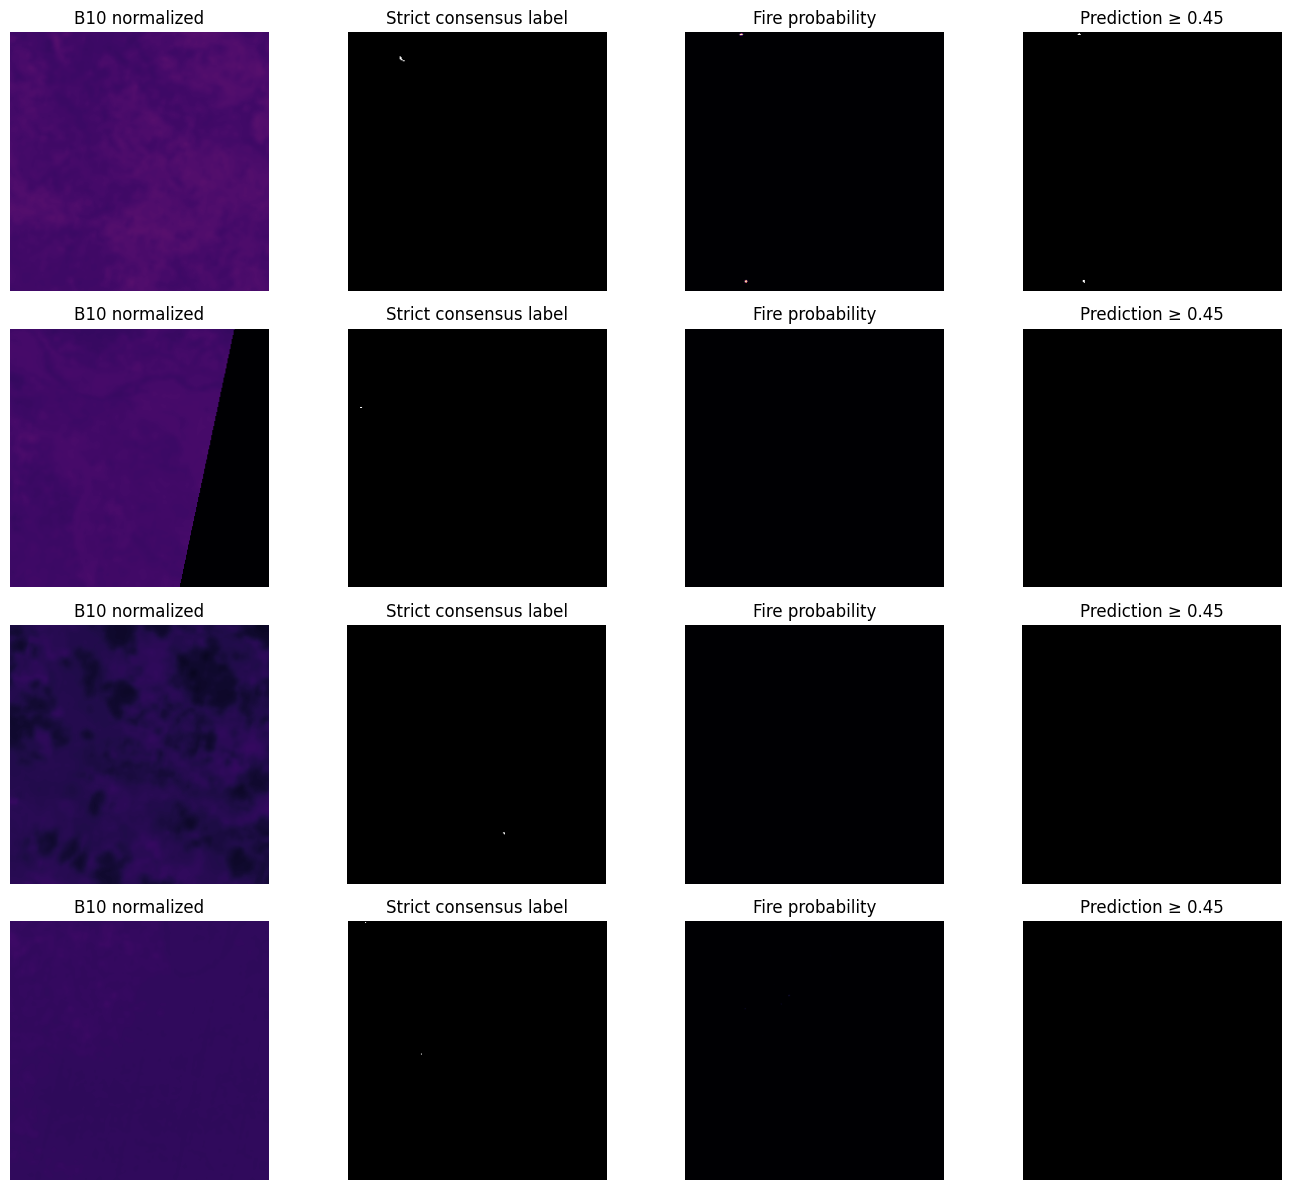

W0924 16:23:56.404000 3493 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TinyUNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TinyUNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX verified: /content/thermal-edge-fire/reports/training_africa_tiny_unet_balanced_v2/tiny_unet_africa_v2.onnx
Saved final archive to: /content/drive/MyDrive/africa_tiny_unet_v2_results.zip


In [ ]:
# ================================================================
# FINAL THRESHOLD, HELD-OUT TEST, VISUALS, ONNX, DRIVE EXPORT
# ================================================================

# Needed once for ONNX export in recent Colab/PyTorch versions.
!pip -q install onnx onnxscript

import shutil
import zipfile
import onnx

# Reload the best validation-Dice checkpoint, not the final epoch weights.
checkpoint = torch.load(
    OUTPUT_DIR / "best_tiny_unet_v3.pt",
    map_location=device,
    weights_only=False,
)
model.load_state_dict(checkpoint["model_state"])
model.eval()

# Evaluate candidate deployment thresholds on validation data only.
thresholds = np.arange(0.05, 0.51, 0.05)

threshold_results = pd.DataFrame([
    {
        "threshold": float(threshold),
        **evaluate(val_loader, threshold=float(threshold)),
    }
    for threshold in thresholds
])

# Balanced deployment operating point: highest validation Dice.
chosen = threshold_results.sort_values(
    ["dice", "precision"],
    ascending=False,
).iloc[0]

FINAL_THRESHOLD = float(chosen["threshold"])

threshold_results.to_csv(
    OUTPUT_DIR / "validation_threshold_sweep.csv",
    index=False,
)

print("FINAL_THRESHOLD selected from validation:", FINAL_THRESHOLD)
display(threshold_results)

# Evaluate the held-out test set once, using FINAL_THRESHOLD.
test_metrics = evaluate(test_loader, threshold=FINAL_THRESHOLD)

pd.DataFrame([{
    "final_threshold": FINAL_THRESHOLD,
    **test_metrics,
}]).to_csv(
    OUTPUT_DIR / "heldout_test_metrics.csv",
    index=False,
)

print("HELD-OUT ALL-AFRICA TEST METRICS")
print(test_metrics)

# Visual check using the same deployment threshold.
images, masks = next(iter(test_loader))

with torch.no_grad():
    probabilities = torch.sigmoid(model(images.to(device))).cpu()

n = min(4, len(images))
fig, axes = plt.subplots(n, 4, figsize=(14, 3 * n), squeeze=False)

for i in range(n):
    axes[i, 0].imshow(images[i, 0], cmap="inferno", vmin=0, vmax=1)
    axes[i, 0].set_title("B10 normalized")

    axes[i, 1].imshow(masks[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title("Strict consensus label")

    axes[i, 2].imshow(probabilities[i, 0], cmap="magma", vmin=0, vmax=1)
    axes[i, 2].set_title("Fire probability")

    axes[i, 3].imshow(
        probabilities[i, 0] >= FINAL_THRESHOLD,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[i, 3].set_title(f"Prediction ≥ {FINAL_THRESHOLD:.2f}")

    for ax in axes[i]:
        ax.axis("off")

plt.tight_layout()

figure_path = OUTPUT_DIR / "heldout_predictions.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

# Export model. The ONNX output is logits, so deployment must apply:
# sigmoid(logits) >= FINAL_THRESHOLD.
onnx_path = OUTPUT_DIR / "tiny_unet_africa_v3.onnx"

example = torch.zeros(1, 1, 256, 256, device=device)

torch.onnx.export(
    model,
    example,
    str(onnx_path),
    input_names=["thermal_b10"],
    output_names=["fire_logits"],
    opset_version=17,
)

onnx.checker.check_model(onnx.load(str(onnx_path)))
print("ONNX verified:", onnx_path)

# Package only final artefacts.
result_files = []

for pattern in ("*.pt", "*.onnx", "*.csv", "*.png"):
    result_files.extend(OUTPUT_DIR.glob(pattern))

archive_path = Path("/content/africa_tiny_unet_v3_results.zip")

with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as archive:
    for file_path in result_files:
        archive.write(file_path, arcname=file_path.name)

drive_path = Path("/content/drive/MyDrive") / archive_path.name
shutil.copy2(archive_path, drive_path)

print("Saved final archive to:", drive_path)